# PPO path-count study: complete result analysis

This notebook compares **different synthetic path counts within the same source model** and asks how path diversity affects PPO learning, out-of-sample performance, and equity.

**Scope and success criteria**

- Compare only matched `study = path-count` PPO runs; do not mix source models when attributing a path-count effect.
- Include PPO learning curves, an exact performance comparison table and plot, and continuous OOS equity curves.
- Add paired rolling-window uncertainty, path-count win rates, and data-completeness checks.
- Read existing JSON/CSV training logs and evaluation artifacts only. **This notebook never trains a model and never runs evaluation.**
- Fail loudly when no completed path-count suite—or any artifact required for the requested analysis—is available.

The main decision is whether adding paths gives a repeatable benefit large enough to justify preferring a larger synthetic set for each generator family.


In [1]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter, PercentFormatter, ScalarFormatter

SEED = 20260821
RNG = np.random.default_rng(SEED)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 160,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#475569",
        "axes.labelcolor": "#1F2937",
        "axes.titlecolor": "#111827",
        "axes.grid": True,
        "grid.color": "#E5E7EB",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.8,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "semibold",
        "legend.frameon": False,
        "lines.linewidth": 2.0,
    }
)

PATH_COLORS = {
    10: "#2563EB",   # blue
    50: "#D4A72C",   # gold
    100: "#E67E22",  # orange
    250: "#6B7D32",  # olive
    500: "#D75A8A",  # pink
}
PATH_MARKERS = {10: "o", 50: "s", 100: "^", 250: "D", 500: "P"}
SOURCE_COLORS = ["#2563EB", "#E67E22", "#6B7D32", "#D75A8A", "#D4A72C"]


## 1. Locate the latest completed experiment suite

`RUN_MODE = None` prefers `full` and falls back to `smoke`. Set it explicitly to require one mode. The loader resolves a stale absolute path through the local suite id, which keeps the notebook usable if the repository is moved.


In [2]:
RUN_MODE: str | None = 'full'  # None -> prefer full, then smoke
TICKER_GROUP: str | None = None
COMMISSION_NAME: str | None = None


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "configs" / "synthetic_vs_real.json").is_file()
            and (candidate / "results" / "ppo_synthetic_vs_real").is_dir()
        ):
            return candidate
    raise FileNotFoundError(
        "Cannot locate the FinRL_Exp repository root. Start Jupyter inside the repository "
        "or one of its subdirectories."
    )


def resolve_latest_suite(study_root: Path, requested_mode: str | None) -> tuple[str, Path, dict]:
    modes = [requested_mode] if requested_mode else ["full", "smoke"]
    attempted: list[str] = []
    for mode in modes:
        pointer_path = study_root / mode / "latest_suite.json"
        attempted.append(str(pointer_path))
        if not pointer_path.is_file():
            continue
        pointer = json.loads(pointer_path.read_text())
        suite_id = pointer.get("suite_id")
        manifest_candidates = []
        if pointer.get("manifest_path"):
            manifest_candidates.append(Path(pointer["manifest_path"]))
        if suite_id:
            manifest_candidates.append(study_root / mode / "suites" / suite_id / "manifest.json")
        for manifest_path in manifest_candidates:
            if manifest_path.is_file():
                manifest = json.loads(manifest_path.read_text())
                if manifest.get("study") != "path-count":
                    raise RuntimeError(
                        f"Expected study='path-count', found {manifest.get('study')!r} in {manifest_path}."
                    )
                return mode, manifest_path.parent, manifest
    raise FileNotFoundError(
        "No completed study path-count experiment suite was found. Checked:\n- "
        + "\n- ".join(attempted)
        + "\nRun the experiment first; this notebook intentionally does not train or evaluate."
    )


REPO_ROOT = find_repo_root()
STUDY_ROOT = REPO_ROOT / "results" / "ppo_synthetic_vs_real" / "path-count"
RUN_MODE, SUITE_DIR, manifest = resolve_latest_suite(STUDY_ROOT, RUN_MODE)
SUITE_ID = str(manifest["suite_id"])

display(
    Markdown(
        f"**Loaded:** `{RUN_MODE}` suite `{SUITE_ID}`  \n"
        f"**Created:** `{manifest.get('created_at_utc', 'unknown')}`  \n"
        f"**Suite directory:** `{SUITE_DIR.relative_to(REPO_ROOT)}`"
    )
)


**Loaded:** `full` suite `344dae519ffe`  
**Created:** `2026-08-21T20:52:48.767093+00:00`  
**Suite directory:** `results/ppo_synthetic_vs_real/path-count/full/suites/344dae519ffe`

In [3]:
REQUIRED_ARTIFACTS = {
    "test_metrics.csv": {
        "window_id", "ticker_group", "commission_name", "seed", "group",
        "study", "synthetic_source_model", "synthetic_path_count",
        "cumulative_return", "cagr", "sharpe", "annualized_volatility",
        "max_drawdown", "turnover", "best_timestep",
    },
    "continuous_metrics.csv": {
        "ticker_group", "commission_name", "seed", "group", "study",
        "synthetic_source_model", "synthetic_path_count", "final_value",
        "cumulative_return", "cagr", "sharpe", "annualized_volatility",
        "max_drawdown", "turnover",
    },
    "continuous_equity_curves.csv": {
        "date", "ticker_group", "commission_name", "seed", "group", "study",
        "synthetic_source_model", "synthetic_path_count", "growth_of_one",
    },
}


def read_required_csv(filename: str, required_columns: set[str]) -> pd.DataFrame:
    path = SUITE_DIR / filename
    if not path.is_file():
        raise FileNotFoundError(
            f"Required path-count artifact is missing: {path}. "
            "The suite is incomplete; this notebook will not train or evaluate to replace it."
        )
    frame = pd.read_csv(path)
    if frame.empty:
        raise RuntimeError(f"Required path-count artifact is empty: {path}")
    missing = sorted(required_columns - set(frame.columns))
    if missing:
        raise RuntimeError(f"{filename} is missing required columns: {missing}")
    studies = set(frame["study"].dropna().astype(str).unique())
    if studies != {"path-count"}:
        raise RuntimeError(f"{filename} contains unexpected study values: {sorted(studies)}")
    return frame


test_metrics = read_required_csv("test_metrics.csv", REQUIRED_ARTIFACTS["test_metrics.csv"])
continuous_metrics = read_required_csv(
    "continuous_metrics.csv", REQUIRED_ARTIFACTS["continuous_metrics.csv"]
)
equity_curves = read_required_csv(
    "continuous_equity_curves.csv", REQUIRED_ARTIFACTS["continuous_equity_curves.csv"]
)
equity_curves["date"] = pd.to_datetime(equity_curves["date"], errors="raise")


def select_single_context(frame: pd.DataFrame, column: str, override: str | None) -> str:
    available = sorted(frame[column].dropna().astype(str).unique())
    if override is not None:
        if override not in available:
            raise ValueError(f"{column}={override!r} is unavailable. Choose one of {available}.")
        return override
    if len(available) != 1:
        raise ValueError(
            f"Multiple {column} values are present: {available}. Set the corresponding "
            "configuration variable so heterogeneous experiments are not averaged together."
        )
    return available[0]


TICKER_GROUP = select_single_context(continuous_metrics, "ticker_group", TICKER_GROUP)
COMMISSION_NAME = select_single_context(continuous_metrics, "commission_name", COMMISSION_NAME)


def context_filter(frame: pd.DataFrame) -> pd.DataFrame:
    return frame.loc[
        frame["ticker_group"].astype(str).eq(TICKER_GROUP)
        & frame["commission_name"].astype(str).eq(COMMISSION_NAME)
    ].copy()


test_metrics = context_filter(test_metrics)
continuous_metrics = context_filter(continuous_metrics)
equity_curves = context_filter(equity_curves)
if test_metrics.empty or continuous_metrics.empty or equity_curves.empty:
    raise RuntimeError("The selected context has no complete path-count result rows.")


## 2. Experimental design and data quality

The comparison is nested within source model. Training timesteps, policy architecture, real/synthetic episode mix, transaction cost, rolling schedule, and seed policy come from the saved manifest/status files. Path count is the varying factor.


In [4]:
study_config = manifest["config"]["studies"]["path-count"]
mode_config = study_config["run_modes"][RUN_MODE]
source_config = study_config["synthetic_path_subsets"]
SOURCE_LABELS = {source: spec["label"] for source, spec in source_config.items()}
expected_pairs = {
    (source, int(count))
    for source, spec in source_config.items()
    for count in spec["counts"]
}


def augmented_only(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.loc[
        frame["synthetic_source_model"].notna()
        & frame["synthetic_path_count"].notna()
    ].copy()
    out["synthetic_path_count"] = out["synthetic_path_count"].astype(int)
    out["source_label"] = out["synthetic_source_model"].map(SOURCE_LABELS).fillna(
        out["synthetic_source_model"]
    )
    return out


window_results = augmented_only(test_metrics)
continuous_results = augmented_only(continuous_metrics)
equity_results = augmented_only(equity_curves)

actual_pairs = set(
    continuous_results[["synthetic_source_model", "synthetic_path_count"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)
missing_pairs = sorted(expected_pairs - actual_pairs)
if missing_pairs:
    raise RuntimeError(
        "The latest suite is missing required continuous results for model/path-count pairs: "
        f"{missing_pairs}"
    )

duplicate_key = [
    "window_id", "ticker_group", "commission_name", "seed",
    "synthetic_source_model", "synthetic_path_count",
]
duplicates = window_results.duplicated(duplicate_key, keep=False)
if duplicates.any():
    raise RuntimeError(
        "Duplicate matched window results detected:\n"
        + window_results.loc[duplicates, duplicate_key].head(10).to_string(index=False)
    )

coverage = (
    window_results.groupby(
        ["source_label", "synthetic_source_model", "synthetic_path_count"], as_index=False
    )
    .agg(
        windows=("window_id", "nunique"),
        seeds=("seed", "nunique"),
        observations=("sharpe", "size"),
        missing_sharpe=("sharpe", lambda s: int(s.isna().sum())),
        first_test=("test_start", "min"),
        last_test=("test_end", "max"),
    )
    .sort_values(["source_label", "synthetic_path_count"])
)
if coverage["missing_sharpe"].sum() > 0:
    raise RuntimeError("Missing Sharpe values prevent a complete path-count comparison.")

design_summary = pd.DataFrame(
    {
        "value": [
            RUN_MODE,
            TICKER_GROUP,
            COMMISSION_NAME,
            mode_config["total_timesteps"],
            mode_config["eval_freq"],
            ", ".join(map(str, mode_config["seeds"])),
            len(manifest["windows"]),
            len(SOURCE_LABELS),
            ", ".join(map(str, sorted({count for _, count in expected_pairs}))),
            manifest["config"]["rolling_schedule"]["name"],
        ]
    },
    index=[
        "run mode", "ticker group", "commission", "PPO timesteps/window",
        "validation frequency", "configured seeds", "rolling windows",
        "source models", "path counts", "rolling schedule",
    ],
)
display(design_summary)
display(coverage.reset_index(drop=True))

if RUN_MODE == "smoke":
    display(
        Markdown(
            "> **Evidence warning:** this is a smoke suite. It has only "
            f"{mode_config['total_timesteps']:,} PPO timesteps per window and validation every "
            f"{mode_config['eval_freq']:,} steps. Treat rankings as pipeline diagnostics, not a "
            "final path-count selection."
        )
    )


,value
run mode,full
ticker group,chosen_10
commission,with_fee
PPO timesteps/window,200000
validation frequency,20000
configured seeds,0
rolling windows,18
source models,3
path counts,"10, 50, 100, 250, 500"
rolling schedule,wf_504_126_63


,source_label,synthetic_source_model,synthetic_path_count,windows,seeds,observations,missing_sharpe,first_test,last_test
0,CN-Diff,cndiff__500_paths,10,18,1,18,0,2020-07-06,2025-01-01
1,CN-Diff,cndiff__500_paths,50,18,1,18,0,2020-07-06,2025-01-01
2,CN-Diff,cndiff__500_paths,100,18,1,18,0,2020-07-06,2025-01-01
3,CN-Diff,cndiff__500_paths,250,18,1,18,0,2020-07-06,2025-01-01
4,CN-Diff,cndiff__500_paths,500,18,1,18,0,2020-07-06,2025-01-01
5,NS-Diff,nsdiff__500_paths,10,18,1,18,0,2020-07-06,2025-01-01
6,NS-Diff,nsdiff__500_paths,50,18,1,18,0,2020-07-06,2025-01-01
7,NS-Diff,nsdiff__500_paths,100,18,1,18,0,2020-07-06,2025-01-01
8,NS-Diff,nsdiff__500_paths,250,18,1,18,0,2020-07-06,2025-01-01
9,NS-Diff,nsdiff__500_paths,500,18,1,18,0,2020-07-06,2025-01-01


## 3. PPO learning curves

**Chart contract:** within each synthetic source model, compare mean real-validation reward over PPO timesteps across path counts. The upper row shows raw means. The lower row shows paired reward deltas against 10 paths in the same window/seed, with normal-approximation 95% confidence bands. This separates nearly coincident smoke-run curves without hiding the underlying reward level. Path count uses a stable color and marker across the notebook.


In [5]:
TRAIN_CACHE_ROOT = REPO_ROOT / "results" / "ppo_synthetic_vs_real" / "train_cache"


def resolve_cache_dir(raw_path: str) -> Path:
    recorded = Path(raw_path)
    candidates = [recorded, TRAIN_CACHE_ROOT / recorded.name]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(
        f"Training-result cache directory is missing: {raw_path}. "
        "Learning curves cannot be reconstructed without saved logs."
    )


validation_frames: list[pd.DataFrame] = []
training_frames: list[pd.DataFrame] = []
missing_logs: list[str] = []
seen_refs: set[tuple[str, str, str]] = set()
synthetic_variants = manifest.get("synthetic_variants", {})

for ref in manifest.get("cache_provenance", []):
    group = str(ref.get("group", ""))
    if not group.startswith("real_synthetic::"):
        continue
    variant_name = group.split("::", 1)[1]
    variant = synthetic_variants.get(variant_name)
    if not isinstance(variant, dict) or not {"source_model", "path_count"} <= set(variant):
        raise RuntimeError(
            f"Manifest cache provenance references an invalid synthetic variant: {variant_name}"
        )
    cache_dir = resolve_cache_dir(ref["training_cache_dir"])
    ref_key = (str(ref.get("window_id")), str(ref.get("run_id")), str(cache_dir))
    if ref_key in seen_refs:
        continue
    seen_refs.add(ref_key)

    status_path = cache_dir / "status.json"
    if not status_path.is_file():
        missing_logs.append(str(status_path))
        continue
    status = json.loads(status_path.read_text())
    if str(ref.get("ticker_group", status.get("ticker_group"))) != TICKER_GROUP:
        continue
    if str(status.get("commission_name")) != COMMISSION_NAME:
        continue

    source = str(variant["source_model"])
    count = int(variant["path_count"])
    common = {
        "window_id": str(ref.get("window_id", status.get("window_id"))),
        "seed": int(status["seed"]),
        "synthetic_source_model": source,
        "source_label": SOURCE_LABELS.get(source, source),
        "synthetic_path_count": count,
        "cache_dir": str(cache_dir),
    }

    for filename, required, destination in [
        (
            "validation_log.csv",
            {"timesteps", "real_valid_reward", "train_reward_mean", "is_best"},
            validation_frames,
        ),
        (
            "training_log.csv",
            {"timesteps", "episode_reward", "episode_length"},
            training_frames,
        ),
    ]:
        log_path = cache_dir / filename
        if not log_path.is_file():
            missing_logs.append(str(log_path))
            continue
        log = pd.read_csv(log_path)
        absent = sorted(required - set(log.columns))
        if log.empty or absent:
            raise RuntimeError(
                f"Invalid learning log {log_path}: empty={log.empty}, missing_columns={absent}"
            )
        destination.append(log.assign(**common))

if missing_logs:
    raise FileNotFoundError(
        "Saved learning logs required for the report are missing. Examples:\n- "
        + "\n- ".join(missing_logs[:10])
    )
if not validation_frames or not training_frames:
    raise FileNotFoundError(
        "No saved PPO learning logs were found for the selected path-count suite. "
        "This notebook will not train or evaluate to create them."
    )

validation_log = pd.concat(validation_frames, ignore_index=True)
training_log = pd.concat(training_frames, ignore_index=True)

loaded_pairs = set(
    validation_log[["synthetic_source_model", "synthetic_path_count"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)
if expected_pairs - loaded_pairs:
    raise RuntimeError(
        "Learning logs are incomplete for model/path-count pairs: "
        f"{sorted(expected_pairs - loaded_pairs)}"
    )

learning_coverage = (
    validation_log.groupby(["source_label", "synthetic_path_count"], as_index=False)
    .agg(
        windows=("window_id", "nunique"),
        seeds=("seed", "nunique"),
        checkpoints=("timesteps", "nunique"),
        max_timestep=("timesteps", "max"),
    )
    .sort_values(["source_label", "synthetic_path_count"])
)
display(learning_coverage)


,source_label,synthetic_path_count,windows,seeds,checkpoints,max_timestep
0,CN-Diff,10,18,1,11,200000
1,CN-Diff,50,18,1,11,200000
2,CN-Diff,100,18,1,11,200000
3,CN-Diff,250,18,1,11,200000
4,CN-Diff,500,18,1,11,200000
5,NS-Diff,10,18,1,11,200000
6,NS-Diff,50,18,1,11,200000
7,NS-Diff,100,18,1,11,200000
8,NS-Diff,250,18,1,11,200000
9,NS-Diff,500,18,1,11,200000


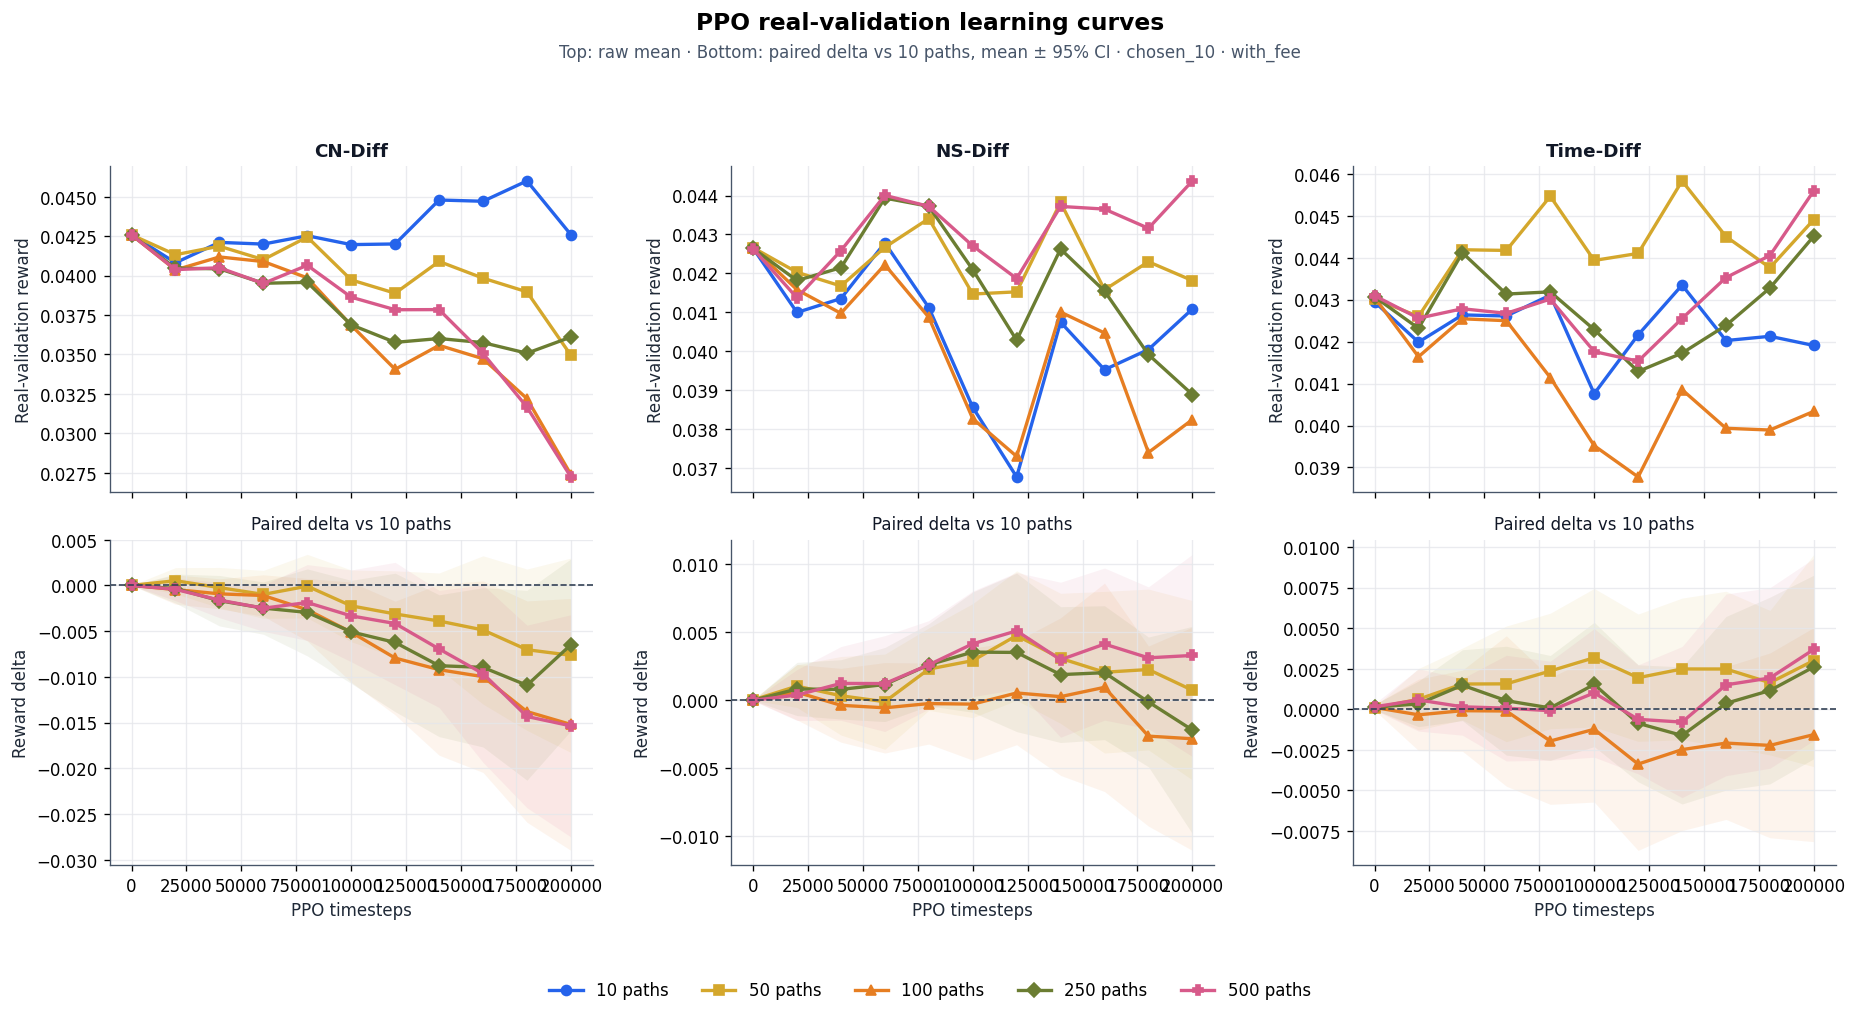

In [6]:
validation_curve = (
    validation_log.groupby(
        ["synthetic_source_model", "source_label", "synthetic_path_count", "timesteps"],
        as_index=False,
    )["real_valid_reward"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
sources = sorted(SOURCE_LABELS, key=lambda source: SOURCE_LABELS[source])
path_counts = sorted({count for _, count in expected_pairs})
validation_delta_frames: list[pd.DataFrame] = []
for source in sources:
    source_log = validation_log.loc[validation_log["synthetic_source_model"].eq(source)]
    baseline_count = int(source_log["synthetic_path_count"].min())
    join_key = ["window_id", "seed", "timesteps"]
    baseline = source_log.loc[
        source_log["synthetic_path_count"].eq(baseline_count),
        join_key + ["real_valid_reward"],
    ].rename(columns={"real_valid_reward": "baseline_reward"})
    for count in sorted(c for c in source_log["synthetic_path_count"].unique() if c != baseline_count):
        comparison = source_log.loc[
            source_log["synthetic_path_count"].eq(count),
            join_key + ["real_valid_reward"],
        ].merge(baseline, on=join_key, how="inner", validate="one_to_one")
        comparison["reward_delta"] = comparison["real_valid_reward"] - comparison["baseline_reward"]
        comparison["synthetic_source_model"] = source
        comparison["source_label"] = SOURCE_LABELS[source]
        comparison["synthetic_path_count"] = int(count)
        validation_delta_frames.append(comparison)

validation_delta = pd.concat(validation_delta_frames, ignore_index=True)
validation_delta_curve = (
    validation_delta.groupby(
        ["synthetic_source_model", "source_label", "synthetic_path_count", "timesteps"]
    )["reward_delta"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
validation_delta_curve["ci95"] = (
    1.96
    * validation_delta_curve["std"].fillna(0.0)
    / np.sqrt(validation_delta_curve["count"].clip(lower=1))
)

fig, axes = plt.subplots(2, len(sources), figsize=(5.2 * len(sources), 8.0), sharex="col")
axes = np.asarray(axes).reshape(2, len(sources))

for col, source in enumerate(sources):
    ax = axes[0, col]
    panel = validation_curve.loc[validation_curve["synthetic_source_model"].eq(source)]
    for count in path_counts:
        line = panel.loc[panel["synthetic_path_count"].eq(count)].sort_values("timesteps")
        if line.empty:
            continue
        ax.plot(
            line["timesteps"], line["mean"],
            color=PATH_COLORS.get(count, "#475569"),
            marker=PATH_MARKERS.get(count, "o"),
            label=f"{count} paths",
        )
    ax.set_title(SOURCE_LABELS[source])
    ax.set_ylabel("Real-validation reward")
    ax.ticklabel_format(axis="x", style="plain")
    ax.spines[["top", "right"]].set_visible(False)

    delta_ax = axes[1, col]
    delta_panel = validation_delta_curve.loc[
        validation_delta_curve["synthetic_source_model"].eq(source)
    ]
    for count in path_counts[1:]:
        line = delta_panel.loc[delta_panel["synthetic_path_count"].eq(count)].sort_values("timesteps")
        if line.empty:
            continue
        delta_ax.plot(
            line["timesteps"], line["mean"],
            color=PATH_COLORS.get(count, "#475569"),
            marker=PATH_MARKERS.get(count, "o"),
            label=f"{count} vs 10",
        )
        delta_ax.fill_between(
            line["timesteps"].to_numpy(),
            (line["mean"] - line["ci95"]).to_numpy(),
            (line["mean"] + line["ci95"]).to_numpy(),
            color=PATH_COLORS.get(count, "#475569"), alpha=0.08, linewidth=0,
        )
    delta_ax.axhline(0.0, color="#334155", linewidth=1.0, linestyle="--")
    delta_ax.set_title("Paired delta vs 10 paths", fontsize=10, fontweight="normal")
    delta_ax.set_xlabel("PPO timesteps")
    delta_ax.set_ylabel("Reward delta")
    delta_ax.ticklabel_format(axis="x", style="plain")
    delta_ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("PPO real-validation learning curves", y=1.015, fontsize=14, fontweight="bold")
fig.text(
    0.5, 0.982,
    f"Top: raw mean · Bottom: paired delta vs 10 paths, mean ± 95% CI · {TICKER_GROUP} · {COMMISSION_NAME}",
    ha="center", va="top", color="#475569",
)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(5, len(labels)), bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(rect=(0, 0.05, 1, 0.94))
plt.show()

checkpoint_count = int(validation_log["timesteps"].nunique())
if checkpoint_count < 8:
    display(
        Markdown(
            f"> Only **{checkpoint_count} validation checkpoints** are available. The lines connect "
            "discrete observations and should not be interpreted as a well-resolved convergence trajectory."
        )
    )


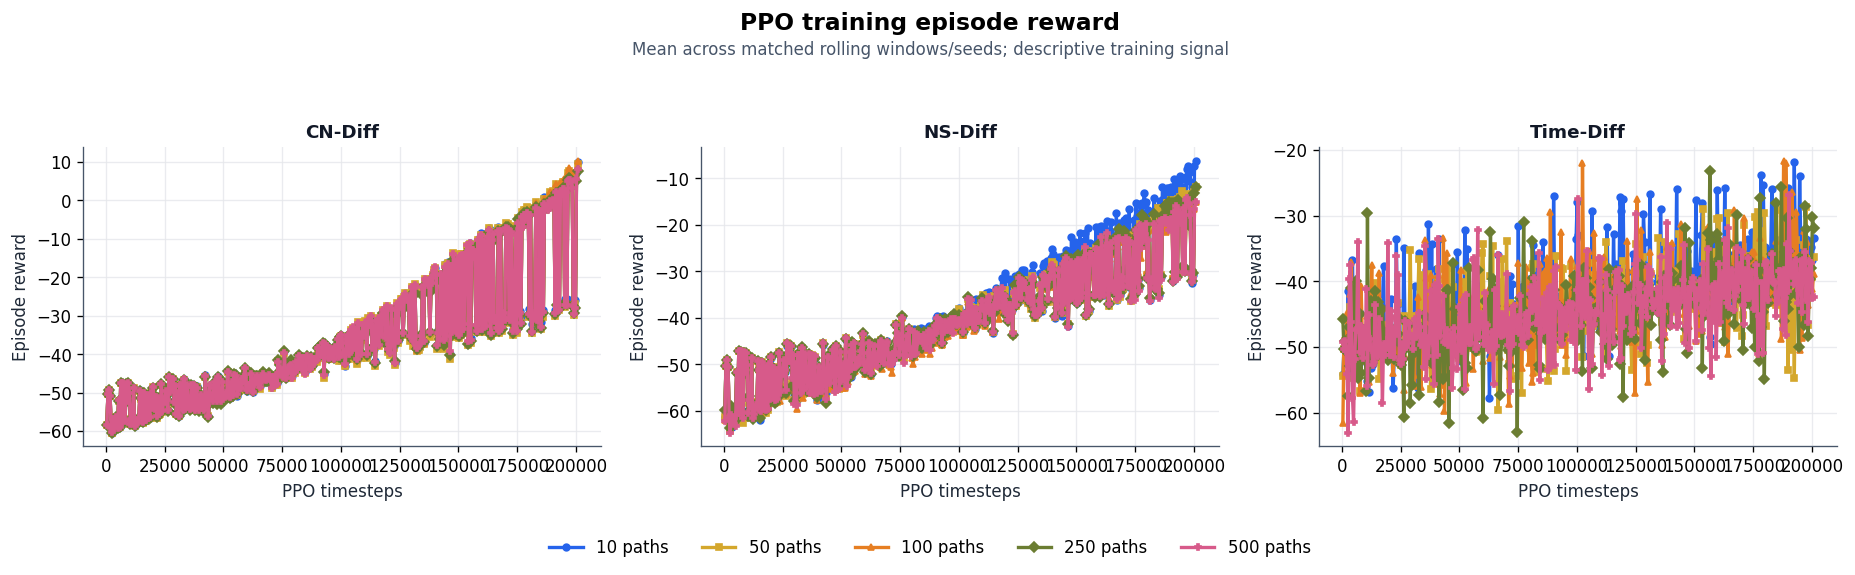

In [7]:
training_curve = (
    training_log.groupby(
        ["synthetic_source_model", "source_label", "synthetic_path_count", "timesteps"],
        as_index=False,
    )["episode_reward"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
fig, axes = plt.subplots(1, len(sources), figsize=(5.2 * len(sources), 4.4), sharey=False)
axes = np.atleast_1d(axes)
for ax, source in zip(axes, sources):
    panel = training_curve.loc[training_curve["synthetic_source_model"].eq(source)]
    for count in path_counts:
        line = panel.loc[panel["synthetic_path_count"].eq(count)].sort_values("timesteps")
        if line.empty:
            continue
        ax.plot(
            line["timesteps"], line["mean"],
            color=PATH_COLORS.get(count, "#475569"),
            marker=PATH_MARKERS.get(count, "o"), markersize=4,
            label=f"{count} paths",
        )
    ax.set_title(SOURCE_LABELS[source])
    ax.set_xlabel("PPO timesteps")
    ax.set_ylabel("Episode reward")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("PPO training episode reward", y=1.03, fontsize=14, fontweight="bold")
fig.text(
    0.5, 0.975,
    "Mean across matched rolling windows/seeds; descriptive training signal",
    ha="center", va="top", color="#475569",
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(5, len(labels)), bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(rect=(0, 0.07, 1, 0.93))
plt.show()


## 4. Performance comparison table

Continuous OOS metrics summarize the stitched rolling evaluation. Window-level mean/dispersion and paired win rates show whether a result is broad or driven by a small part of the test history. The 10-path variant is the within-model reference because it is the smallest configured nested subset.


In [8]:
INITIAL_AMOUNT = float(manifest["config"]["initial_amount"])

performance = (
    continuous_results.groupby(
        ["synthetic_source_model", "source_label", "synthetic_path_count"], as_index=False
    )
    .agg(
        continuous_runs=("sharpe", "size"),
        final_value=("final_value", "mean"),
        cumulative_return=("cumulative_return", "mean"),
        cagr=("cagr", "mean"),
        sharpe=("sharpe", "mean"),
        annualized_volatility=("annualized_volatility", "mean"),
        max_drawdown=("max_drawdown", "mean"),
        turnover=("turnover", "mean"),
    )
)
performance["growth_multiple"] = performance["final_value"] / INITIAL_AMOUNT

window_summary = (
    window_results.groupby(
        ["synthetic_source_model", "source_label", "synthetic_path_count"], as_index=False
    )
    .agg(
        window_sharpe_mean=("sharpe", "mean"),
        window_sharpe_std=("sharpe", "std"),
        window_return_mean=("cumulative_return", "mean"),
        window_return_std=("cumulative_return", "std"),
        window_count=("window_id", "nunique"),
    )
)

comparison_rows: list[dict] = []
match_index = ["window_id", "ticker_group", "commission_name", "seed"]
for source, source_frame in window_results.groupby("synthetic_source_model"):
    baseline_count = int(source_frame["synthetic_path_count"].min())
    sharpe_wide = source_frame.pivot(index=match_index, columns="synthetic_path_count", values="sharpe")
    if baseline_count not in sharpe_wide:
        raise RuntimeError(f"Missing {baseline_count}-path Sharpe baseline for {source}.")
    return_wide = source_frame.pivot(
        index=match_index, columns="synthetic_path_count", values="cumulative_return"
    )
    ranks = source_frame.groupby(match_index + ["synthetic_source_model"])["sharpe"].rank(
        method="min", ascending=False
    )
    ranked = source_frame.assign(window_rank=ranks)
    leader_rate = ranked.groupby("synthetic_path_count")["window_rank"].apply(
        lambda s: float((s == 1).mean())
    )
    for count in sorted(source_frame["synthetic_path_count"].unique()):
        count = int(count)
        sharpe_delta = (sharpe_wide[count] - sharpe_wide[baseline_count]).dropna()
        return_delta = (return_wide[count] - return_wide[baseline_count]).dropna()
        comparison_rows.append(
            {
                "synthetic_source_model": source,
                "synthetic_path_count": count,
                "sharpe_delta_vs_min": float(sharpe_delta.mean()),
                "sharpe_win_rate_vs_min": np.nan if count == baseline_count else float((sharpe_delta > 0).mean()),
                "return_delta_vs_min": float(return_delta.mean()),
                "return_win_rate_vs_min": np.nan if count == baseline_count else float((return_delta > 0).mean()),
                "window_leader_rate": float(leader_rate.get(count, np.nan)),
            }
        )

comparisons = pd.DataFrame(comparison_rows)
performance = (
    performance.merge(
        window_summary,
        on=["synthetic_source_model", "source_label", "synthetic_path_count"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        comparisons,
        on=["synthetic_source_model", "synthetic_path_count"],
        how="left",
        validate="one_to_one",
    )
    .sort_values(["source_label", "synthetic_path_count"])
)
performance["sharpe_rank_within_model"] = performance.groupby("synthetic_source_model")["sharpe"].rank(
    method="min", ascending=False
).astype(int)

comparison_table = performance[
    [
        "source_label", "synthetic_path_count", "growth_multiple", "cumulative_return",
        "cagr", "sharpe", "annualized_volatility", "max_drawdown", "turnover",
        "window_sharpe_mean", "window_sharpe_std", "sharpe_delta_vs_min",
        "sharpe_win_rate_vs_min", "window_leader_rate", "sharpe_rank_within_model",
    ]
].rename(
    columns={
        "source_label": "Source model",
        "synthetic_path_count": "Paths",
        "growth_multiple": "Final growth",
        "cumulative_return": "Cum. return",
        "cagr": "CAGR",
        "sharpe": "Continuous Sharpe",
        "annualized_volatility": "Ann. volatility",
        "max_drawdown": "Max drawdown",
        "turnover": "Turnover",
        "window_sharpe_mean": "Window Sharpe mean",
        "window_sharpe_std": "Window Sharpe std",
        "sharpe_delta_vs_min": "Mean Δ Sharpe vs 10",
        "sharpe_win_rate_vs_min": "Sharpe win rate vs 10",
        "window_leader_rate": "Window leader rate",
        "sharpe_rank_within_model": "Sharpe rank",
    }
)

display(
    comparison_table.style.format(
        {
            "Final growth": "{:.3f}×",
            "Cum. return": "{:.2%}",
            "CAGR": "{:.2%}",
            "Continuous Sharpe": "{:.3f}",
            "Ann. volatility": "{:.2%}",
            "Max drawdown": "{:.2%}",
            "Turnover": "{:.3f}",
            "Window Sharpe mean": "{:.3f}",
            "Window Sharpe std": "{:.3f}",
            "Mean Δ Sharpe vs 10": "{:+.3f}",
            "Sharpe win rate vs 10": lambda x: "—" if pd.isna(x) else f"{x:.1%}",
            "Window leader rate": "{:.1%}",
        },
        na_rep="—",
    ).background_gradient(subset=["Continuous Sharpe"], cmap="Blues")
)


,Source model,Paths,Final growth,Cum. return,CAGR,Continuous Sharpe,Ann. volatility,Max drawdown,Turnover,Window Sharpe mean,Window Sharpe std,Mean Δ Sharpe vs 10,Sharpe win rate vs 10,Window leader rate,Sharpe rank
0,CN-Diff,10,1.344×,34.39%,6.81%,0.509,15.20%,-26.87%,0.019,0.765,1.479,+0.000,—,22.2%,5
1,CN-Diff,50,1.480×,48.05%,9.14%,0.646,15.35%,-27.61%,0.018,0.888,1.600,+0.123,55.6%,27.8%,1
2,CN-Diff,100,1.421×,42.06%,8.14%,0.600,14.90%,-26.01%,0.016,0.802,1.578,+0.037,55.6%,27.8%,2
3,CN-Diff,250,1.371×,37.10%,7.28%,0.539,15.20%,-26.61%,0.015,0.730,1.553,-0.035,44.4%,0.0%,4
4,CN-Diff,500,1.411×,41.08%,7.97%,0.590,14.88%,-26.62%,0.016,0.806,1.580,+0.041,55.6%,22.2%,3
5,NS-Diff,10,1.377×,37.69%,7.39%,0.551,14.97%,-26.29%,0.016,0.758,1.545,+0.000,—,11.1%,5
6,NS-Diff,50,1.479×,47.88%,9.11%,0.671,14.59%,-21.86%,0.015,0.815,1.416,+0.056,44.4%,22.2%,1
7,NS-Diff,100,1.469×,46.94%,8.95%,0.659,14.64%,-25.93%,0.016,0.880,1.595,+0.122,66.7%,22.2%,2
8,NS-Diff,250,1.408×,40.81%,7.92%,0.583,15.02%,-25.29%,0.017,0.790,1.525,+0.031,44.4%,27.8%,3
9,NS-Diff,500,1.397×,39.68%,7.73%,0.572,14.98%,-24.05%,0.016,0.775,1.494,+0.017,61.1%,16.7%,4


## 5. Performance comparison plots

**Chart contract:** show exact continuous OOS metrics against path count. Each line is one source model; path count is on a log scale because the configured levels are multiplicative. Percent axes retain their natural units, and max drawdown remains negative so “closer to zero” is visibly better.


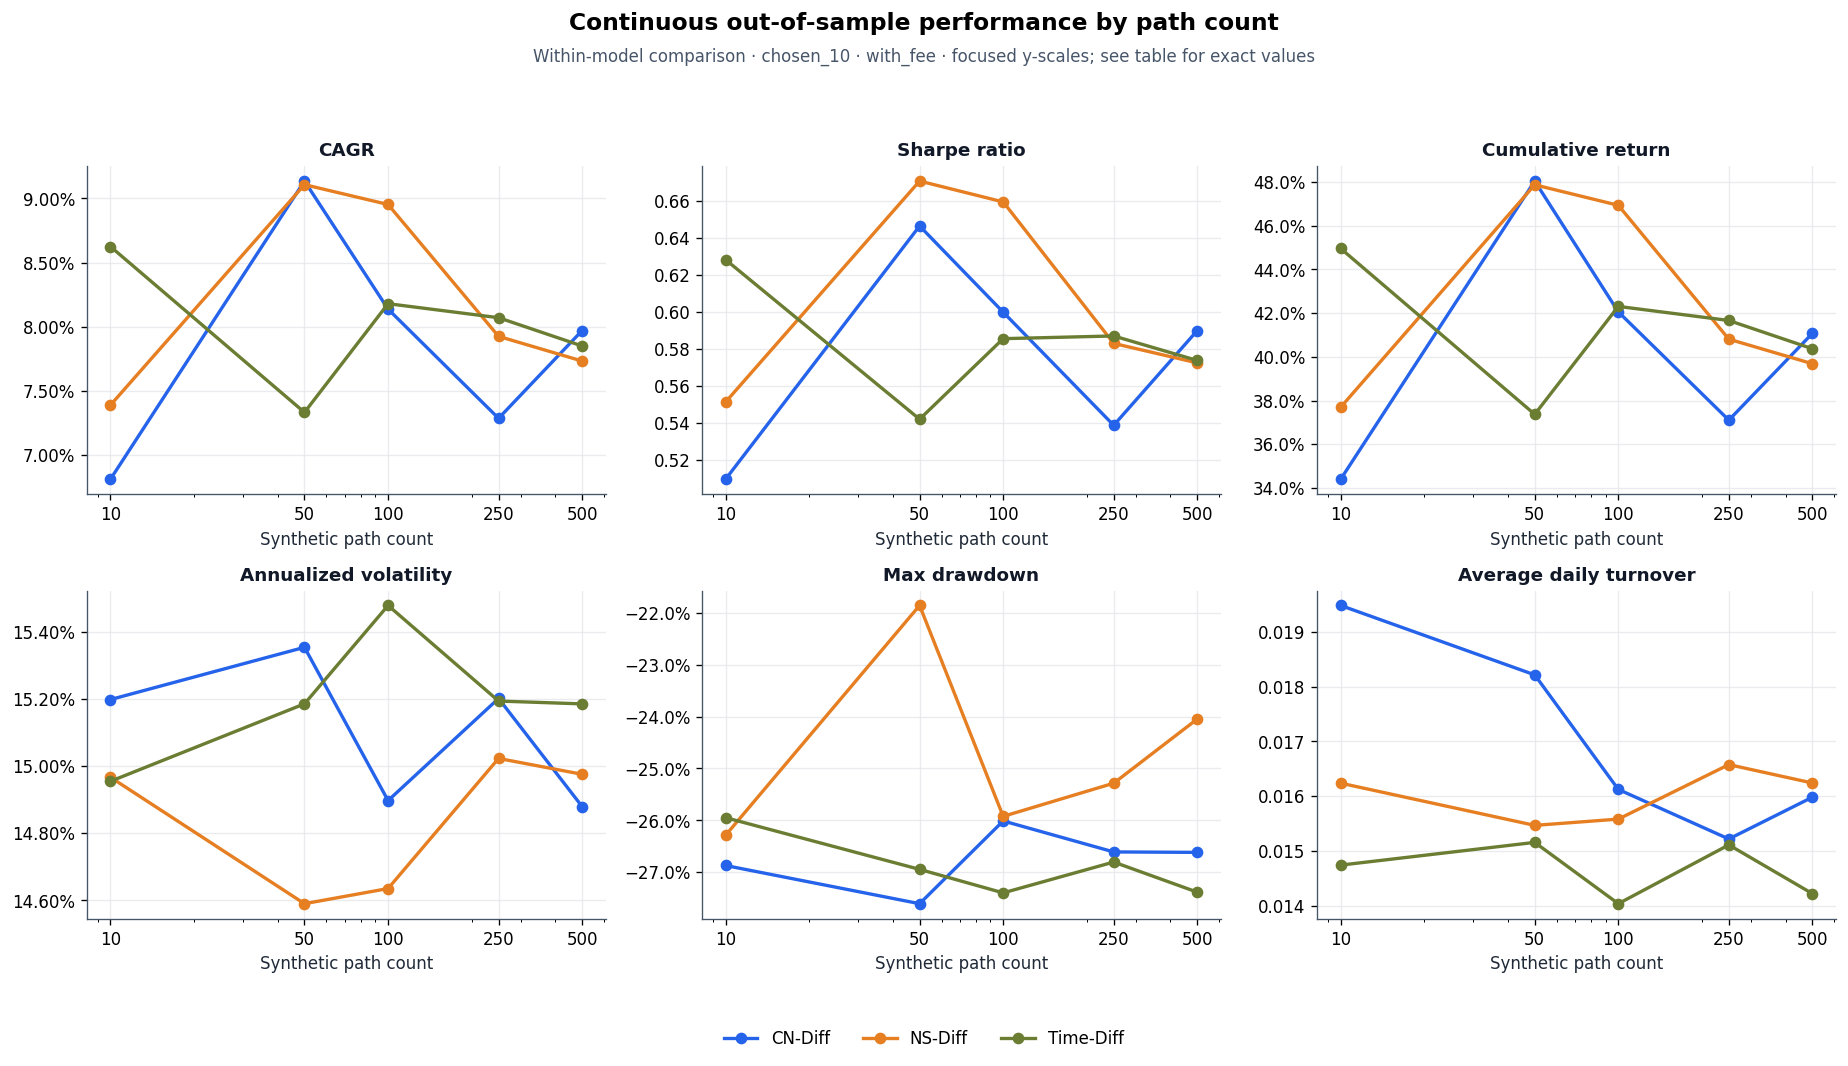

In [9]:
metric_specs = [
    ("cagr", "CAGR", "percent"),
    ("sharpe", "Sharpe ratio", "number"),
    ("cumulative_return", "Cumulative return", "percent"),
    ("annualized_volatility", "Annualized volatility", "percent"),
    ("max_drawdown", "Max drawdown", "percent"),
    ("turnover", "Average daily turnover", "number"),
]
source_color = {
    source: SOURCE_COLORS[i % len(SOURCE_COLORS)]
    for i, source in enumerate(sources)
}

fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.5))
for ax, (metric, title, unit) in zip(axes.ravel(), metric_specs):
    for source in sources:
        line = performance.loc[performance["synthetic_source_model"].eq(source)].sort_values(
            "synthetic_path_count"
        )
        ax.plot(
            line["synthetic_path_count"], line[metric],
            color=source_color[source], marker="o", label=SOURCE_LABELS[source],
        )
    ax.set_xscale("log")
    ax.set_xticks(path_counts)
    ax.get_xaxis().set_major_formatter(ScalarFormatter())
    ax.set_xlabel("Synthetic path count")
    ax.set_title(title)
    if unit == "percent":
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Continuous out-of-sample performance by path count", y=1.02, fontsize=14, fontweight="bold")
fig.text(
    0.5, 0.985,
    f"Within-model comparison · {TICKER_GROUP} · {COMMISSION_NAME} · focused y-scales; see table for exact values",
    ha="center", va="top", color="#475569",
)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(labels), bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=(0, 0.06, 1, 0.95))
plt.show()


## 6. Paired rolling-window robustness

A continuous metric can hide when an advantage occurred. The paired analysis compares each larger subset with the 10-path subset in the **same** source model, rolling window, seed, ticker group, and commission setting.

- CI: deterministic bootstrap 95% interval for the mean paired delta across windows.
- Win rate: share of non-tied matched windows where the larger count beats 10 paths.
- Sign-test p-value: exact two-sided test of equal win/loss probability; it is descriptive here because rolling windows are not fully independent.


In [10]:
def bootstrap_mean_ci(values: pd.Series, n_boot: int = 10_000) -> tuple[float, float]:
    array = values.dropna().to_numpy(dtype=float)
    if len(array) < 2:
        return (np.nan, np.nan)
    indices = RNG.integers(0, len(array), size=(n_boot, len(array)))
    means = array[indices].mean(axis=1)
    low, high = np.quantile(means, [0.025, 0.975])
    return float(low), float(high)


def exact_two_sided_sign_p(values: pd.Series) -> float:
    array = values.dropna().to_numpy(dtype=float)
    array = array[~np.isclose(array, 0.0)]
    wins = int((array > 0).sum())
    losses = int((array < 0).sum())
    n = wins + losses
    if n == 0:
        return 1.0
    k = min(wins, losses)
    lower_tail = sum(math.comb(n, i) for i in range(k + 1)) / (2**n)
    return min(1.0, 2.0 * lower_tail)


paired_rows: list[dict] = []
metrics_for_pairs = {"sharpe": "Sharpe", "cagr": "CAGR"}
match_index = ["window_id", "ticker_group", "commission_name", "seed"]

for source, source_frame in window_results.groupby("synthetic_source_model"):
    baseline_count = int(source_frame["synthetic_path_count"].min())
    for metric, metric_label in metrics_for_pairs.items():
        wide = source_frame.pivot(index=match_index, columns="synthetic_path_count", values=metric)
        for count in sorted(c for c in wide.columns if int(c) != baseline_count):
            count = int(count)
            delta = (wide[count] - wide[baseline_count]).dropna()
            ci_low, ci_high = bootstrap_mean_ci(delta)
            non_ties = delta.loc[~np.isclose(delta, 0.0)]
            paired_rows.append(
                {
                    "synthetic_source_model": source,
                    "source_label": SOURCE_LABELS[source],
                    "metric": metric,
                    "Metric": metric_label,
                    "Comparison": f"{count} vs {baseline_count}",
                    "Paths": count,
                    "Matched windows": len(delta),
                    "Mean paired delta": float(delta.mean()),
                    "Median paired delta": float(delta.median()),
                    "CI low": ci_low,
                    "CI high": ci_high,
                    "Win rate": float((non_ties > 0).mean()) if len(non_ties) else np.nan,
                    "Sign-test p": exact_two_sided_sign_p(delta),
                }
            )

paired_comparison = pd.DataFrame(paired_rows).sort_values(
    ["source_label", "metric", "Paths"]
)
paired_display = paired_comparison[
    [
        "source_label", "Metric", "Comparison", "Matched windows", "Mean paired delta",
        "Median paired delta", "CI low", "CI high", "Win rate", "Sign-test p",
    ]
].rename(columns={"source_label": "Source model"})

display(
    paired_display.style.format(
        {
            "Mean paired delta": "{:+.4f}",
            "Median paired delta": "{:+.4f}",
            "CI low": "{:+.4f}",
            "CI high": "{:+.4f}",
            "Win rate": "{:.1%}",
            "Sign-test p": "{:.3f}",
        },
        na_rep="—",
    )
)


,Source model,Metric,Comparison,Matched windows,Mean paired delta,Median paired delta,CI low,CI high,Win rate,Sign-test p
4,CN-Diff,CAGR,50 vs 10,18,+0.0308,+0.0016,+0.0028,+0.0607,55.6%,0.815
5,CN-Diff,CAGR,100 vs 10,18,+0.0161,+0.0023,-0.0110,+0.0474,50.0%,1.000
6,CN-Diff,CAGR,250 vs 10,18,+0.0070,-0.0056,-0.0211,+0.0391,44.4%,0.815
7,CN-Diff,CAGR,500 vs 10,18,+0.0155,+0.0023,-0.0084,+0.0443,61.1%,0.481
0,CN-Diff,Sharpe,50 vs 10,18,+0.1227,+0.0059,-0.0207,+0.2973,55.6%,0.815
1,CN-Diff,Sharpe,100 vs 10,18,+0.0374,+0.0361,-0.1360,+0.2300,55.6%,0.815
2,CN-Diff,Sharpe,250 vs 10,18,-0.0348,-0.0528,-0.1852,+0.1221,44.4%,0.815
3,CN-Diff,Sharpe,500 vs 10,18,+0.0409,+0.0896,-0.0908,+0.1651,55.6%,0.815
12,NS-Diff,CAGR,50 vs 10,18,+0.0117,-0.0041,-0.0103,+0.0372,44.4%,0.815
13,NS-Diff,CAGR,100 vs 10,18,+0.0186,+0.0092,-0.0040,+0.0448,55.6%,0.815


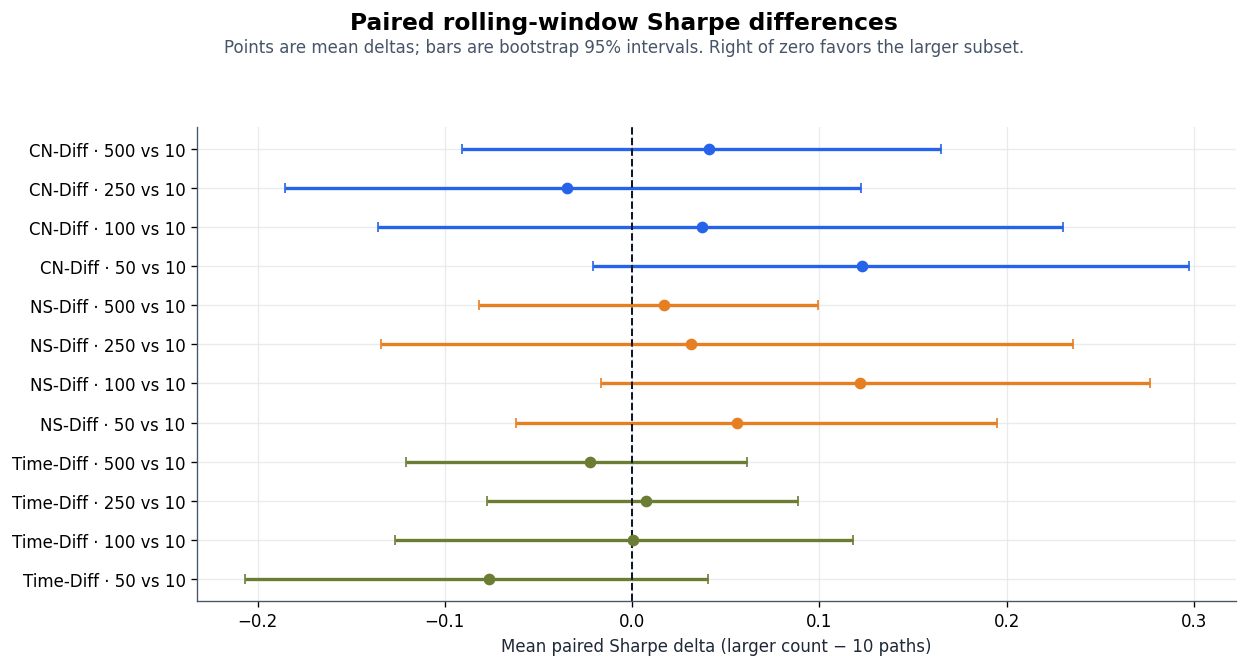

In [11]:
sharpe_pairs = paired_comparison.loc[paired_comparison["metric"].eq("sharpe")].copy()
sharpe_pairs = sharpe_pairs.sort_values(["source_label", "Paths"], ascending=[False, True]).reset_index(drop=True)
y = np.arange(len(sharpe_pairs))

fig, ax = plt.subplots(figsize=(10.5, max(5.6, 0.44 * len(sharpe_pairs))))
for idx, row in sharpe_pairs.iterrows():
    x = row["Mean paired delta"]
    xerr = np.array([[x - row["CI low"]], [row["CI high"] - x]])
    source = row["synthetic_source_model"]
    ax.errorbar(
        x, idx, xerr=xerr, fmt="o", capsize=3,
        color=source_color[source], ecolor=source_color[source],
    )
ax.axvline(0.0, color="#111827", linewidth=1.2, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{row['source_label']} · {int(row['Paths'])} vs 10" for _, row in sharpe_pairs.iterrows()]
)
ax.set_xlabel("Mean paired Sharpe delta (larger count − 10 paths)")
fig.suptitle("Paired rolling-window Sharpe differences", y=0.985, fontsize=14, fontweight="bold")
fig.text(
    0.5, 0.945,
    "Points are mean deltas; bars are bootstrap 95% intervals. Right of zero favors the larger subset.",
    ha="center", va="top", color="#475569",
)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()


## 7. Continuous out-of-sample equity curves

**Chart contract:** each panel holds the source model fixed and varies only path count. Equity is normalized to 1.0 at the beginning of the stitched OOS period. The gray dashed line is the saved real-data PPO baseline and is context—not part of the within-model path-count effect. If multiple seeds are present, the line is the median and the light band is the 10th–90th percentile.


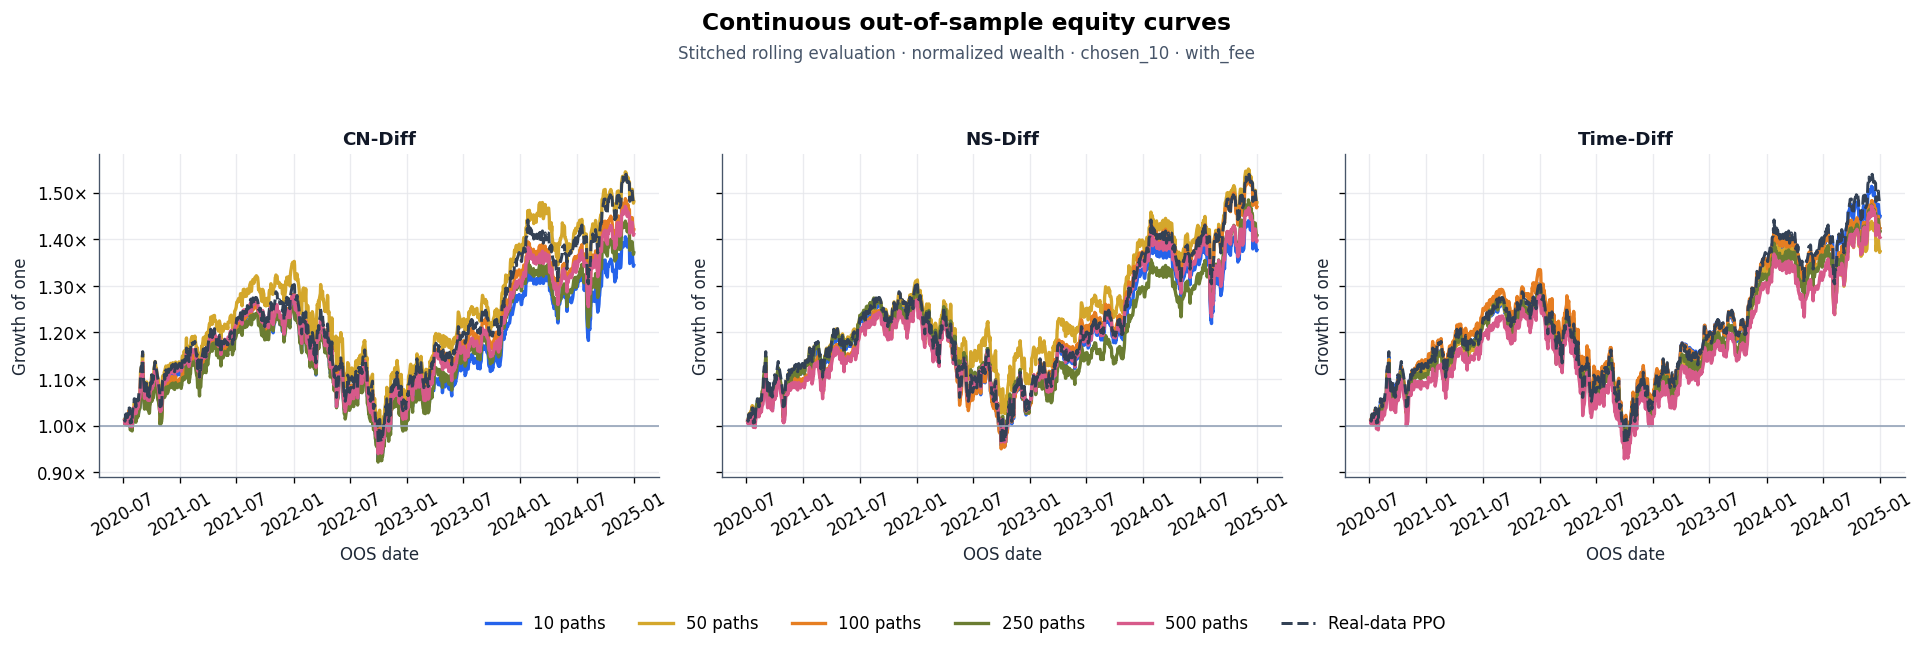

In [12]:
equity_stats = (
    equity_results.groupby(
        ["synthetic_source_model", "source_label", "synthetic_path_count", "date"],
        as_index=False,
    )["growth_of_one"]
    .agg(
        median="median",
        q10=lambda s: s.quantile(0.10),
        q90=lambda s: s.quantile(0.90),
        observations="size",
    )
)

real_equity = equity_curves.loc[equity_curves["group"].eq("real_trained")].copy()
real_stats = (
    real_equity.groupby("date", as_index=False)["growth_of_one"]
    .agg(median="median", q10=lambda s: s.quantile(0.10), q90=lambda s: s.quantile(0.90))
)
if real_stats.empty:
    warnings.warn("The real-data PPO baseline is absent; path-count equity curves will still be shown.")

fig, axes = plt.subplots(1, len(sources), figsize=(5.4 * len(sources), 5.0), sharey=True)
axes = np.atleast_1d(axes)
for ax, source in zip(axes, sources):
    panel = equity_stats.loc[equity_stats["synthetic_source_model"].eq(source)]
    for count in path_counts:
        line = panel.loc[panel["synthetic_path_count"].eq(count)].sort_values("date")
        if line.empty:
            continue
        ax.plot(
            line["date"], line["median"],
            color=PATH_COLORS.get(count, "#475569"),
            label=f"{count} paths",
        )
        if int(line["observations"].max()) > 1:
            ax.fill_between(
                line["date"].to_numpy(), line["q10"].to_numpy(), line["q90"].to_numpy(),
                color=PATH_COLORS.get(count, "#475569"), alpha=0.10, linewidth=0,
            )
    if not real_stats.empty:
        ax.plot(
            real_stats["date"], real_stats["median"],
            color="#334155", linestyle="--", linewidth=1.8, label="Real-data PPO",
        )
    ax.axhline(1.0, color="#94A3B8", linewidth=1.0)
    ax.set_title(SOURCE_LABELS[source])
    ax.set_xlabel("OOS date")
    ax.set_ylabel("Growth of one")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.2f}×"))
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Continuous out-of-sample equity curves", y=1.03, fontsize=14, fontweight="bold")
fig.text(
    0.5, 0.975,
    f"Stitched rolling evaluation · normalized wealth · {TICKER_GROUP} · {COMMISSION_NAME}",
    ha="center", va="top", color="#475569",
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(6, len(labels)), bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(rect=(0, 0.08, 1, 0.93))
plt.show()


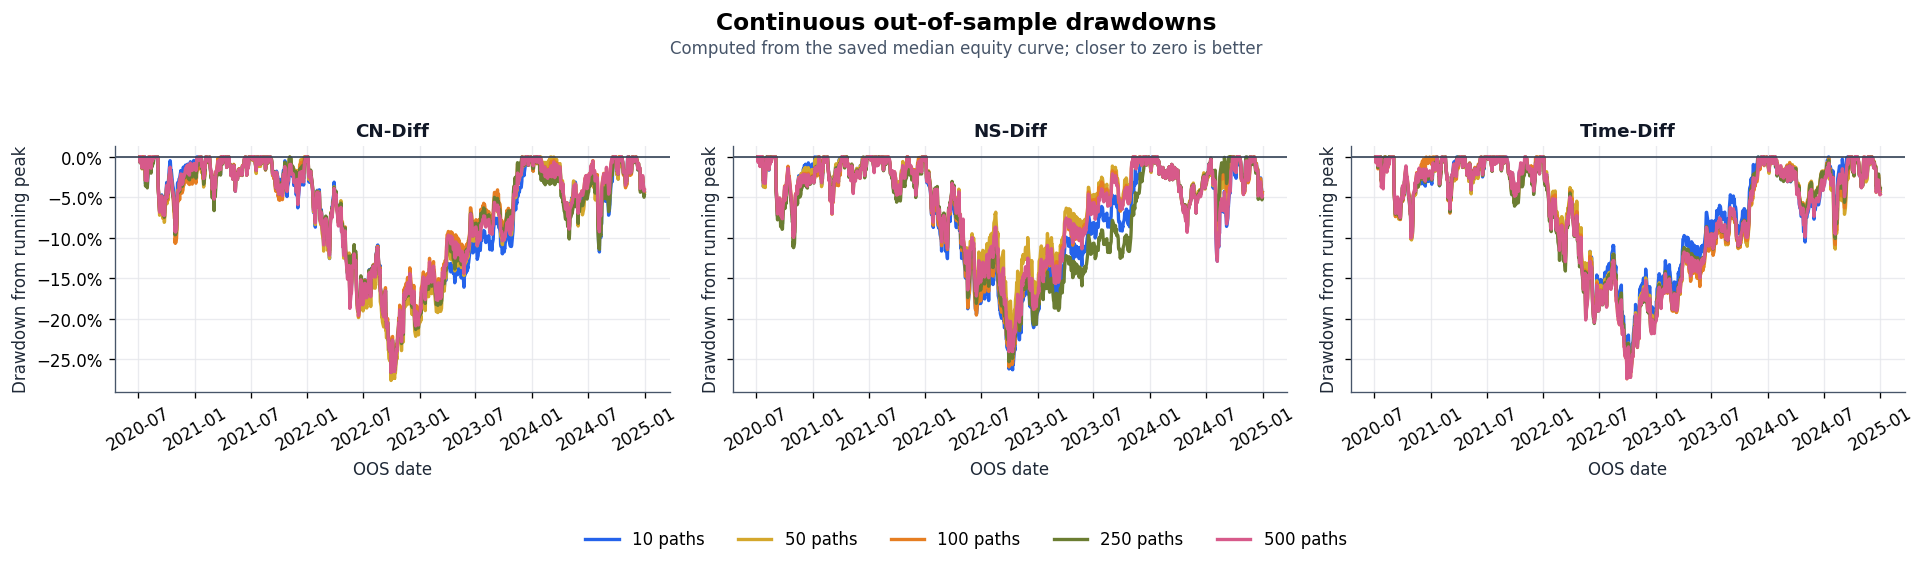

In [13]:
drawdown_stats = equity_stats.sort_values(
    ["synthetic_source_model", "synthetic_path_count", "date"]
).copy()
drawdown_stats["running_peak"] = drawdown_stats.groupby(
    ["synthetic_source_model", "synthetic_path_count"]
)["median"].cummax()
drawdown_stats["drawdown"] = drawdown_stats["median"] / drawdown_stats["running_peak"] - 1.0

fig, axes = plt.subplots(1, len(sources), figsize=(5.4 * len(sources), 4.3), sharey=True)
axes = np.atleast_1d(axes)
for ax, source in zip(axes, sources):
    panel = drawdown_stats.loc[drawdown_stats["synthetic_source_model"].eq(source)]
    for count in path_counts:
        line = panel.loc[panel["synthetic_path_count"].eq(count)].sort_values("date")
        ax.plot(
            line["date"], line["drawdown"],
            color=PATH_COLORS.get(count, "#475569"), label=f"{count} paths",
        )
    ax.axhline(0.0, color="#334155", linewidth=1.0)
    ax.set_title(SOURCE_LABELS[source])
    ax.set_xlabel("OOS date")
    ax.set_ylabel("Drawdown from running peak")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Continuous out-of-sample drawdowns", y=1.03, fontsize=14, fontweight="bold")
fig.text(
    0.5, 0.975,
    "Computed from the saved median equity curve; closer to zero is better",
    ha="center", va="top", color="#475569",
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(5, len(labels)), bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(rect=(0, 0.09, 1, 0.93))
plt.show()


## 8. Decision summary

The following text is generated from the loaded suite, so it updates when a new `full` or `smoke` suite becomes latest. “Best” always means best **within the same source model** on continuous OOS Sharpe.


In [14]:
summary_lines: list[str] = []
for source in sources:
    model_perf = performance.loc[performance["synthetic_source_model"].eq(source)].copy()
    best = model_perf.sort_values(["sharpe", "synthetic_path_count"], ascending=[False, True]).iloc[0]
    min_count = int(model_perf["synthetic_path_count"].min())
    min_row = model_perf.loc[model_perf["synthetic_path_count"].eq(min_count)].iloc[0]
    best_count = int(best["synthetic_path_count"])
    delta = float(best["sharpe"] - min_row["sharpe"])

    if best_count == min_count:
        robustness = "The smallest configured subset is already the continuous-Sharpe leader."
    else:
        pair = sharpe_pairs.loc[
            sharpe_pairs["synthetic_source_model"].eq(source)
            & sharpe_pairs["Paths"].eq(best_count)
        ].iloc[0]
        if pair["CI low"] > 0:
            robustness = "Its paired bootstrap interval is entirely above zero."
        elif pair["CI high"] < 0:
            robustness = "Its paired bootstrap interval is entirely below zero, conflicting with the aggregate rank."
        else:
            robustness = "Its paired bootstrap interval crosses zero, so the window-level advantage is not stable."

    summary_lines.append(
        f"- **{SOURCE_LABELS[source]}:** {best_count} paths has the highest continuous OOS Sharpe "
        f"({best['sharpe']:.3f}), a {delta:+.3f} change from {min_count} paths. "
        f"It leads {best['window_leader_rate']:.1%} of matched windows. {robustness}"
    )

smoke_decision = (
    "- **Decision:** do not finalize a path-count choice from this smoke suite. Run the configured full "
    "study, then rerun this read-only notebook and require agreement between continuous performance, "
    "paired-window uncertainty, and learning behavior."
    if RUN_MODE == "smoke"
    else
    "- **Decision:** prefer a larger path count only when its continuous improvement is material and the "
    "paired-window interval supports the same direction; otherwise choose the smaller near-equivalent subset."
)

caveats = [
    "- **Nested-subset caveat:** each level uses the first N saved paths, so the estimate reflects both path count and the composition/order of that nested subset.",
    "- **Uncertainty caveat:** rolling windows overlap in their train/validation histories; bootstrap intervals and sign tests are descriptive, not independent-sample causal proof.",
    "- **Fixed-budget interpretation:** PPO timesteps are fixed across counts. Path count changes synthetic diversity/exposure, not the optimization budget.",
    "- **No hidden computation:** every number above is derived from saved suite CSV/JSON/log artifacts; no training or evaluation was executed.",
]

display(
    Markdown(
        "### Findings\n\n"
        + "\n".join(summary_lines)
        + "\n\n### Recommendation\n\n"
        + smoke_decision
        + "\n\n### Material caveats\n\n"
        + "\n".join(caveats)
    )
)


### Findings

- **CN-Diff:** 50 paths has the highest continuous OOS Sharpe (0.646), a +0.137 change from 10 paths. It leads 27.8% of matched windows. Its paired bootstrap interval crosses zero, so the window-level advantage is not stable.
- **NS-Diff:** 50 paths has the highest continuous OOS Sharpe (0.671), a +0.119 change from 10 paths. It leads 22.2% of matched windows. Its paired bootstrap interval crosses zero, so the window-level advantage is not stable.
- **Time-Diff:** 10 paths has the highest continuous OOS Sharpe (0.628), a +0.000 change from 10 paths. It leads 16.7% of matched windows. The smallest configured subset is already the continuous-Sharpe leader.

### Recommendation

- **Decision:** prefer a larger path count only when its continuous improvement is material and the paired-window interval supports the same direction; otherwise choose the smaller near-equivalent subset.

### Material caveats

- **Nested-subset caveat:** each level uses the first N saved paths, so the estimate reflects both path count and the composition/order of that nested subset.
- **Uncertainty caveat:** rolling windows overlap in their train/validation histories; bootstrap intervals and sign tests are descriptive, not independent-sample causal proof.
- **Fixed-budget interpretation:** PPO timesteps are fixed across counts. Path count changes synthetic diversity/exposure, not the optimization budget.
- **No hidden computation:** every number above is derived from saved suite CSV/JSON/log artifacts; no training or evaluation was executed.

## Next steps

1. If the loaded suite is `smoke`, complete the configured `full` path-count study and rerun this notebook without changing analysis code.
2. Repeat with additional PPO seeds if path-count rankings remain close; current rolling-window variation does not replace initialization uncertainty.
3. Randomize or rotate the nested path ordering in a follow-up study if the “first N paths” composition could drive the result.
4. Treat generator-family comparisons as a separate question; this notebook estimates path-count effects within each model.
